In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torch
from IPython.core.pylabtools import figsize

In [5]:
w = torchvision.models.alexnet(pretrained=True)
w

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [11]:
# Accessing the models layers
list(w.children()), len(list(w.children())) # Has 3 children

([Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  ),
  AdaptiveAvgPool2d(output_size=(6, 6)),
  Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(

In [18]:
list(w.children())[-1] #  => w.classifier Accessing the last model of the pretrained model

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

> Then what if we want to access the `6` to get change the out_features=100

In [20]:
import torch.nn as nn
list(w.children())[-1][-1] = nn.Linear(in_features=4096, out_features=10) # Here we output 10 classes You can also access using w['name'] of the feature in the block
# Accessing the last layer of the model again
list(w.children())[-1] # w.classifier They are the same

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=10, bias=True)
)

> We are now getting 10 features as output

In [24]:
for param in w.parameters():
    print(param)

Parameter containing:
tensor([[[[ 1.1864e-01,  9.4069e-02,  9.5435e-02,  ...,  5.5822e-02,
            2.1575e-02,  4.9963e-02],
          [ 7.4882e-02,  3.8940e-02,  5.2979e-02,  ...,  2.5709e-02,
           -1.1299e-02,  4.1590e-03],
          [ 7.5425e-02,  3.8779e-02,  5.4930e-02,  ...,  4.3596e-02,
            1.0225e-02,  1.3251e-02],
          ...,
          [ 9.3155e-02,  1.0374e-01,  6.7547e-02,  ..., -2.0277e-01,
           -1.2839e-01, -1.1220e-01],
          [ 4.3544e-02,  6.4916e-02,  3.6164e-02,  ..., -2.0248e-01,
           -1.1376e-01, -1.0719e-01],
          [ 4.7369e-02,  6.2543e-02,  2.4758e-02,  ..., -1.1844e-01,
           -9.5567e-02, -8.3890e-02]],

         [[-7.2634e-02, -5.7996e-02, -8.0661e-02,  ..., -6.0304e-04,
           -2.5309e-02,  2.5471e-02],
          [-6.9042e-02, -6.7562e-02, -7.6367e-02,  ..., -3.9616e-03,
           -3.0402e-02,  1.0477e-02],
          [-9.9517e-02, -8.5592e-02, -1.0521e-01,  ..., -2.6587e-02,
           -2.2777e-02,  6.6451e-03]

In [36]:
def show_img(im, ax=None, figsize=(8,8), title=None):
    if not ax: _,ax = plt.subplots(1,1,figsize=figsize)
    if len(im.shape)==2: im = np.tile(im[:,:,None], 3)
    ax.imshow(im);
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    if title: ax.set_title(title)
    return ax

In [37]:
def show_imgs(ims, rows=1, figsize=(16,8), title=[None]):
    title = title*len(ims) if len(title) == 1 else title
    _,ax = plt.subplots(rows, len(ims)//rows, figsize=figsize)
    [show_img(im,ax_,title=tit) for im,ax_,tit in zip(ims,ax.flatten(),title)]
    return ax

## Looking at alexnet

In [39]:
w.features[0].weight.data, w.features[0].weight.shape

(tensor([[[[ 1.1864e-01,  9.4069e-02,  9.5435e-02,  ...,  5.5822e-02,
             2.1575e-02,  4.9963e-02],
           [ 7.4882e-02,  3.8940e-02,  5.2979e-02,  ...,  2.5709e-02,
            -1.1299e-02,  4.1590e-03],
           [ 7.5425e-02,  3.8779e-02,  5.4930e-02,  ...,  4.3596e-02,
             1.0225e-02,  1.3251e-02],
           ...,
           [ 9.3155e-02,  1.0374e-01,  6.7547e-02,  ..., -2.0277e-01,
            -1.2839e-01, -1.1220e-01],
           [ 4.3544e-02,  6.4916e-02,  3.6164e-02,  ..., -2.0248e-01,
            -1.1376e-01, -1.0719e-01],
           [ 4.7369e-02,  6.2543e-02,  2.4758e-02,  ..., -1.1844e-01,
            -9.5567e-02, -8.3890e-02]],
 
          [[-7.2634e-02, -5.7996e-02, -8.0661e-02,  ..., -6.0304e-04,
            -2.5309e-02,  2.5471e-02],
           [-6.9042e-02, -6.7562e-02, -7.6367e-02,  ..., -3.9616e-03,
            -3.0402e-02,  1.0477e-02],
           [-9.9517e-02, -8.5592e-02, -1.0521e-01,  ..., -2.6587e-02,
            -2.2777e-02,  6.6451e-03],


In [46]:
w = torchvision.models.alexnet(pretrained=True).features[0].weight.data
w

tensor([[[[ 1.1864e-01,  9.4069e-02,  9.5435e-02,  ...,  5.5822e-02,
            2.1575e-02,  4.9963e-02],
          [ 7.4882e-02,  3.8940e-02,  5.2979e-02,  ...,  2.5709e-02,
           -1.1299e-02,  4.1590e-03],
          [ 7.5425e-02,  3.8779e-02,  5.4930e-02,  ...,  4.3596e-02,
            1.0225e-02,  1.3251e-02],
          ...,
          [ 9.3155e-02,  1.0374e-01,  6.7547e-02,  ..., -2.0277e-01,
           -1.2839e-01, -1.1220e-01],
          [ 4.3544e-02,  6.4916e-02,  3.6164e-02,  ..., -2.0248e-01,
           -1.1376e-01, -1.0719e-01],
          [ 4.7369e-02,  6.2543e-02,  2.4758e-02,  ..., -1.1844e-01,
           -9.5567e-02, -8.3890e-02]],

         [[-7.2634e-02, -5.7996e-02, -8.0661e-02,  ..., -6.0304e-04,
           -2.5309e-02,  2.5471e-02],
          [-6.9042e-02, -6.7562e-02, -7.6367e-02,  ..., -3.9616e-03,
           -3.0402e-02,  1.0477e-02],
          [-9.9517e-02, -8.5592e-02, -1.0521e-01,  ..., -2.6587e-02,
           -2.2777e-02,  6.6451e-03],
          ...,
     

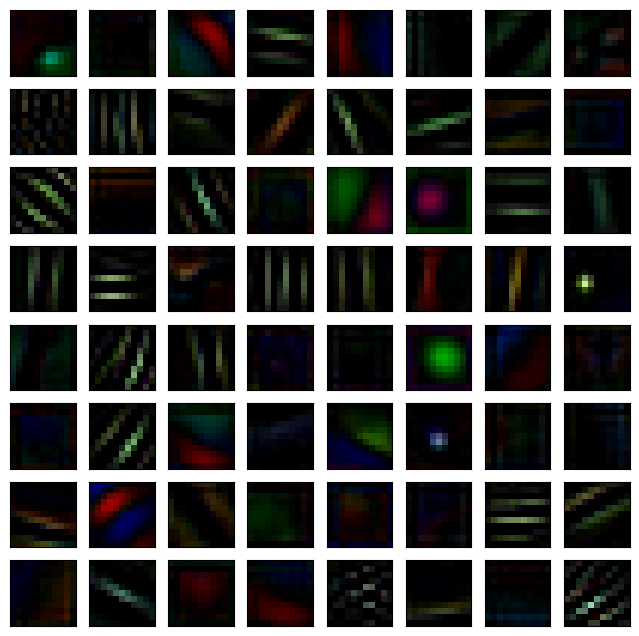

In [48]:
rows = int(np.sqrt(w.shape[0]))
show_imgs(w.numpy().transpose(0,2,3,1).clip(0,1), rows=rows, figsize=(rows,rows));

In [49]:
# With increased contrast
wv = w.view(*w.shape[:1], -1)
mn, mx = wv.min(dim=-1)[0][..., None, None, None], wv.max(dim=-1)[0][..., None, None, None]
wn = ((w- mn)/(mx-mn))

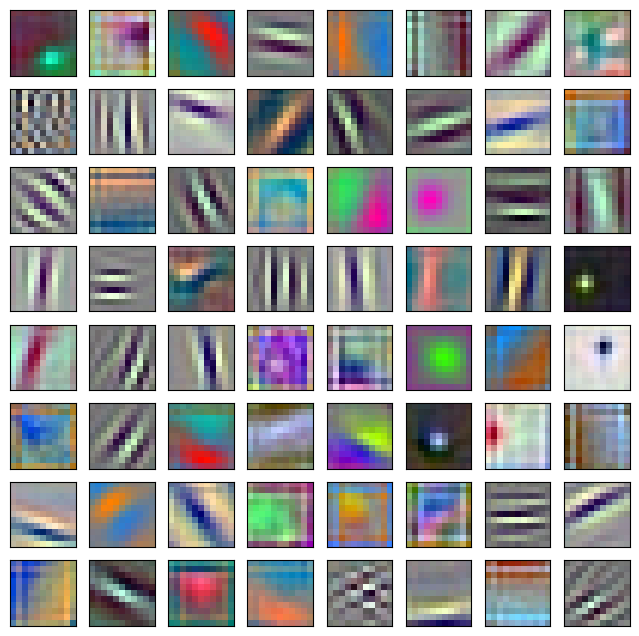

In [50]:
show_imgs(wn.numpy().transpose(0,2,3,1), rows=rows, figsize=(rows,rows));

## Resnet from the scratch

In [52]:
net = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.AdaptiveAvgPool2d(output_size=(4,4)),
    nn.Flatten(),
    nn.Linear(in_features=32*4*4, out_features=10), nn.LeakyReLU(),
)
net

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): LeakyReLU(negative_slope=0.01)
  (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): LeakyReLU(negative_slope=0.01)
  (4): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): LeakyReLU(negative_slope=0.01)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): LeakyReLU(negative_slope=0.01)
  (9): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): LeakyReLU(negative_slope=0.01)
  (11): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): LeakyReLU(negative_slope=0.01)
  (13): AdaptiveAvgPool2d(output_size=(4, 4))
  (14): Flatten(start_dim=1, end_dim=-1)
  (15): Linear(in_features=512, out_features=10, bias=True)
  (16): LeakyReLU(negative_slope=0.01)
)

In [68]:
class ConvRelu(nn.Module):
    def __init__(self, ch, cnt=2):
        super().__init__()
        layers = cnt * [nn.Conv2d(in_channels=ch, out_channels=ch, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(inplace=True)]
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

In [69]:
net1 = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),nn.LeakyReLU(),
    ConvRelu(16),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),nn.LeakyReLU(),
    ConvRelu(32),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=32*4*4, out_features=10)
)
net1

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): LeakyReLU(negative_slope=0.01)
  (2): ConvRelu(
    (block): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): LeakyReLU(negative_slope=0.01)
  (6): ConvRelu(
    (block): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (7): MaxPool2d(kernel_size=2, stride=2, padding

In [70]:
class ConvReluRes(nn.Module):
    def __init__(self, ch, cnt=2):
        super().__init__()
        layers = cnt * [nn.Conv2d(in_channels=ch, out_channels=ch, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(inplace=True)]
        self.resblock = nn.Sequential(*layers)

    def forward(self, x):
        return self.resblock(x) + x  # "+x" in this single line of code makes it a ResNet (and has some serious implications)!
#         return tc.cat((self.resblock(x), x), dim=1)  # DenseNet does this instead

In [73]:
resnet = nn.Sequential(
    nn.Conv2d(in_channels=3,  out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    ConvReluRes(16),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    ConvReluRes(32),
    nn.AdaptiveAvgPool2d((4,4)),
    nn.Flatten(),
    nn.Linear(32*4*4,10)
)
resnet

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): LeakyReLU(negative_slope=0.01)
  (2): ConvReluRes(
    (resblock): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): LeakyReLU(negative_slope=0.01)
  (6): ConvReluRes(
    (resblock): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (7): AdaptiveAvgPool2d(output_size=